# Полный анализ моделей для проекта СМП

EDA, ROC-AUC, Confusion Matrix, Feature Importance и SHAP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
df=pd.read_csv('/content/realistic_ems_dataset_10000.csv')
df.head()

,age,heart_rate,sdnn,anxiety_score,systolic_bp,spo2,chest_pain,dyspnea,dizziness,weakness,hypertension,diabetes,coronary_artery_disease,target
0,71,78.8,66.6,6,132.6,96.6,1,0,0,1,1,0,1,1
1,84,57.5,60.3,5,166.2,100.0,0,1,1,0,0,1,0,1
2,79,115.4,10.0,1,180.0,92.6,0,0,0,1,0,0,1,0
3,75,74.2,39.7,4,146.0,94.7,1,0,0,1,1,1,0,1
4,72,79.8,41.6,0,92.7,100.0,1,0,1,0,0,0,0,0


## Распределение классов

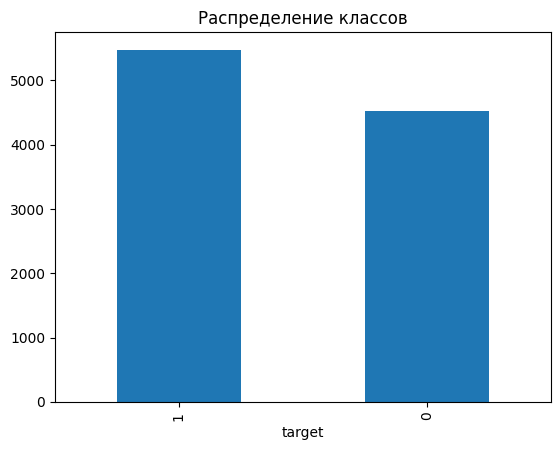

In [3]:
df['target'].value_counts().plot(kind='bar')
plt.title('Распределение классов')
plt.show()

## Корреляционная матрица

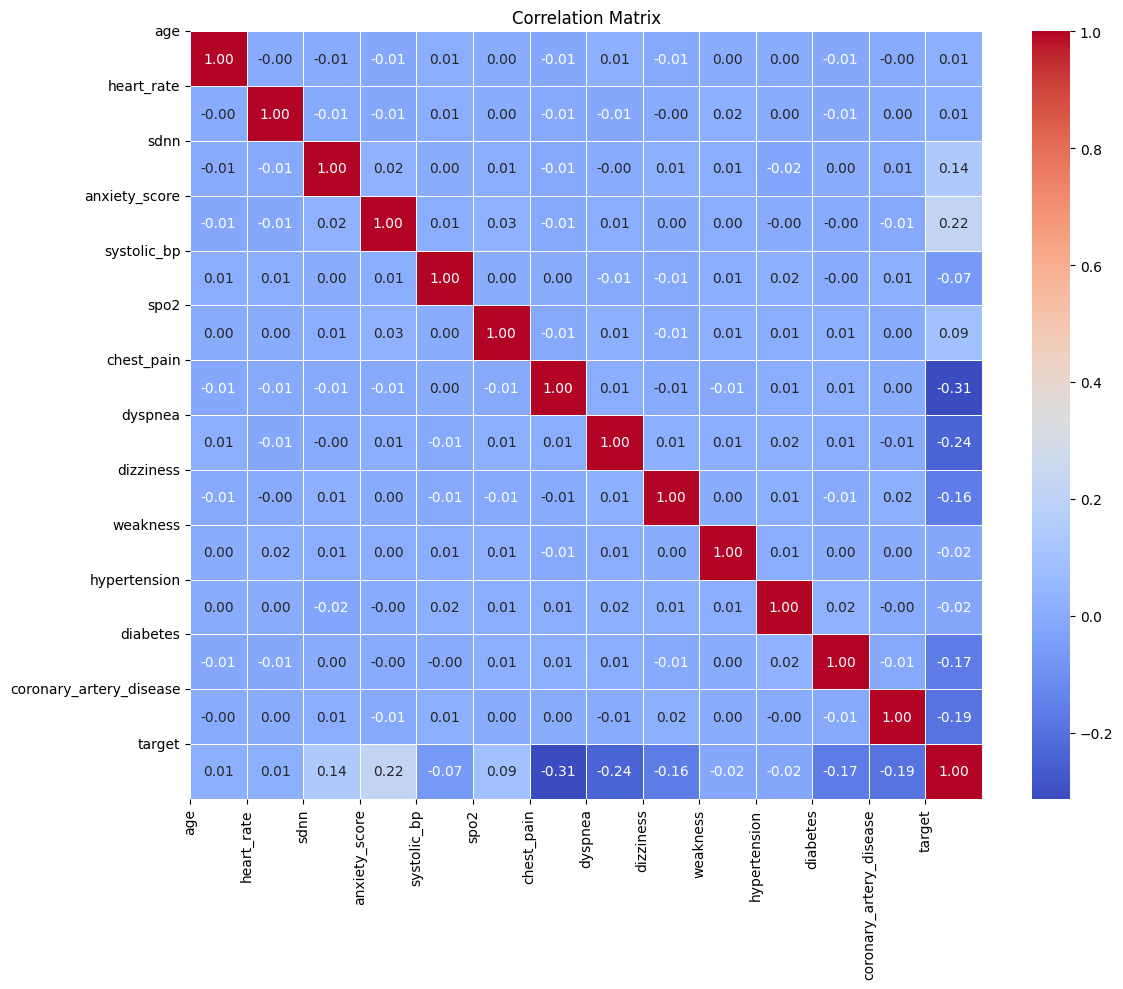

In [19]:
import seaborn as sns

corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.tight_layout()
plt.show()

## Обучение моделей

In [5]:
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
models={
'Logistic Regression':Pipeline([('s',StandardScaler()),('m',LogisticRegression(max_iter=3000))]),
'Random Forest':RandomForestClassifier(n_estimators=300,random_state=42),
'Gradient Boosting':GradientBoostingClassifier(random_state=42),
'SVM (RBF)':Pipeline([('s',StandardScaler()),('m',SVC(kernel='rbf',probability=True,random_state=42))])}
results=[]
roc_data={}
trained={}
for name,m in models.items():
 m.fit(X_train,y_train)
 trained[name]=m
 pred=m.predict(X_test)
 prob=m.predict_proba(X_test)[:,1]
 auc=roc_auc_score(y_test,prob)
 fpr,tpr,_=roc_curve(y_test,prob)
 roc_data[name]=(fpr,tpr,auc)
 results.append([name,accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),auc])
results_df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1','ROC_AUC'])
results_df.sort_values('ROC_AUC',ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.7860,0.786266,0.836530,0.810619,0.876314
1,Random Forest,0.7855,0.795737,0.818265,0.806844,0.862146
3,SVM (RBF),0.7735,0.771574,0.832877,0.801054,0.844495
0,Logistic Regression,0.7585,0.763793,0.809132,0.785809,0.835665


## ROC-кривые

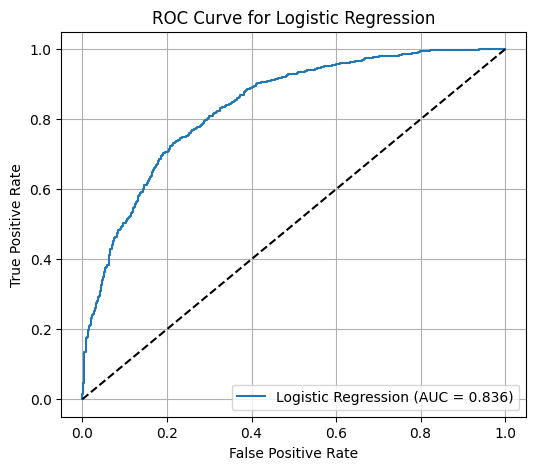

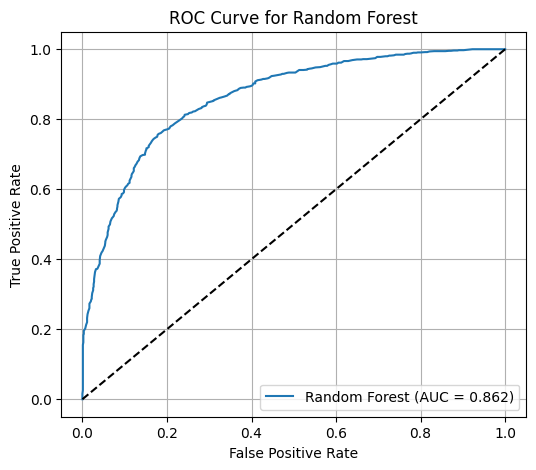

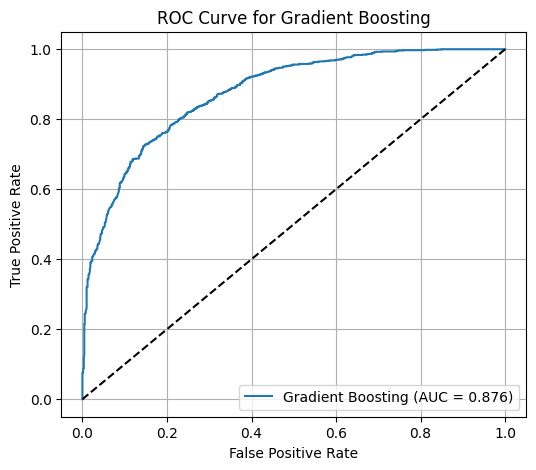

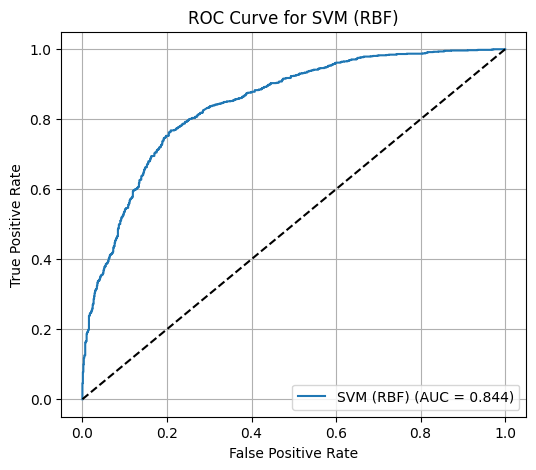

In [15]:
for name, (fpr, tpr, auc) in roc_data.items():
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--') # Add a random guess line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

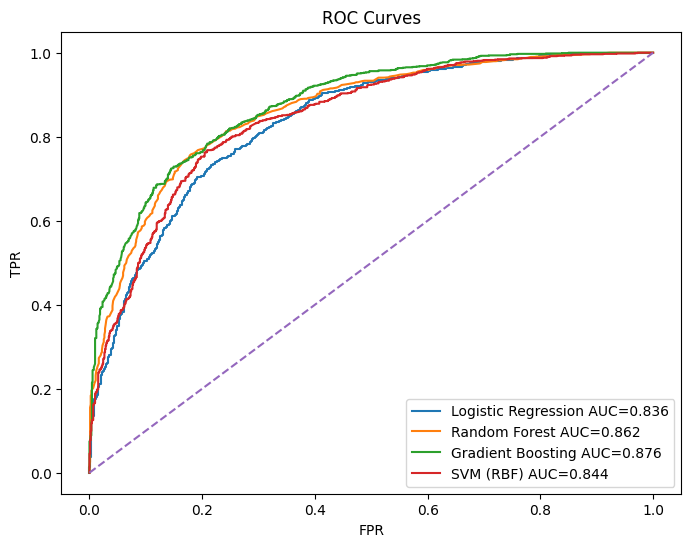

In [6]:
plt.figure(figsize=(8,6))
for n,(fpr,tpr,auc) in roc_data.items():
 plt.plot(fpr,tpr,label=f'{n} AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title('ROC Curves')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.savefig('roc_curve.png',bbox_inches='tight')
plt.show()

In [17]:
print('Сравнение моделей:')
print(results_df.sort_values('ROC_AUC', ascending=False).to_markdown(index=False))

Сравнение моделей:
| Model               |   Accuracy |   Precision |   Recall |       F1 |   ROC_AUC |
|:--------------------|-----------:|------------:|---------:|---------:|----------:|
| Gradient Boosting   |     0.786  |    0.786266 | 0.83653  | 0.810619 |  0.876314 |
| Random Forest       |     0.7855 |    0.795737 | 0.818265 | 0.806844 |  0.862146 |
| SVM (RBF)           |     0.7735 |    0.771574 | 0.832877 | 0.801054 |  0.844495 |
| Logistic Regression |     0.7585 |    0.763793 | 0.809132 | 0.785809 |  0.835665 |


## Матрицы ошибок

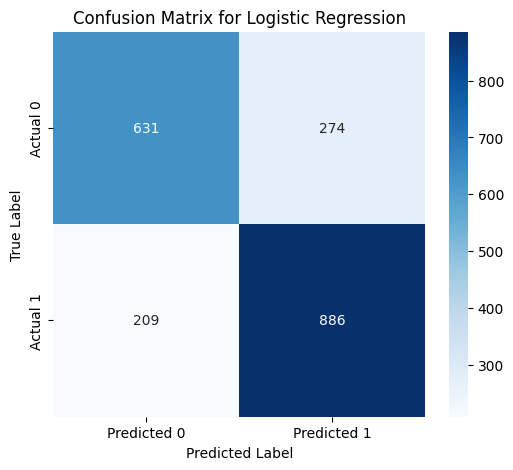

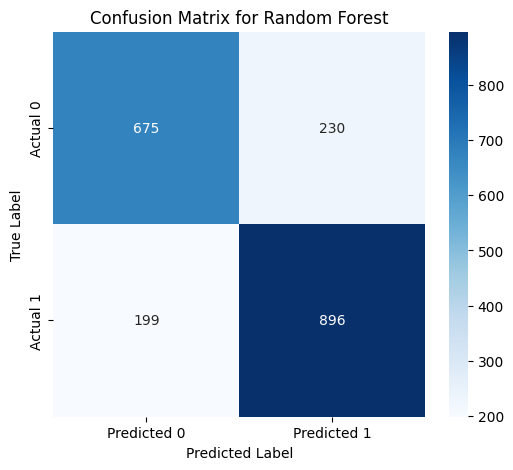

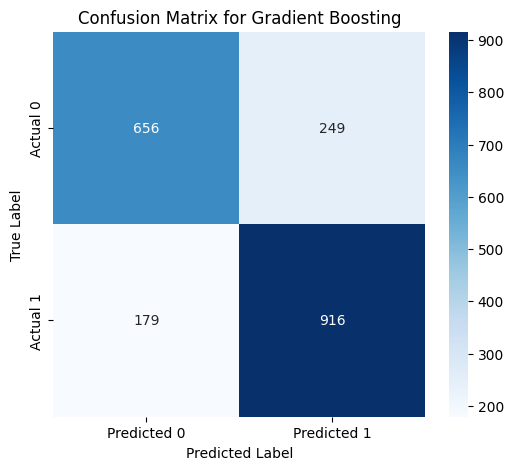

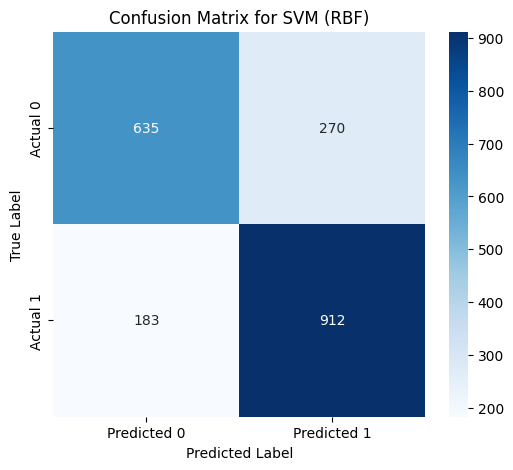

In [13]:
import seaborn as sns
for name,m in trained.items():
 pred=m.predict(X_test)
 cm=confusion_matrix(y_test,pred)

 # Normalize the confusion matrix to show percentages (removed for raw counts)
 # cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

 plt.figure(figsize=(6,5))
 # Use seaborn.heatmap for a better visual and to display values
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
 plt.title(f'Confusion Matrix for {name}')
 plt.xlabel('Predicted Label')
 plt.ylabel('True Label')
 plt.savefig(f'confusion_{name}.png',bbox_inches='tight')
 plt.show()

## Важность признаков (Random Forest)

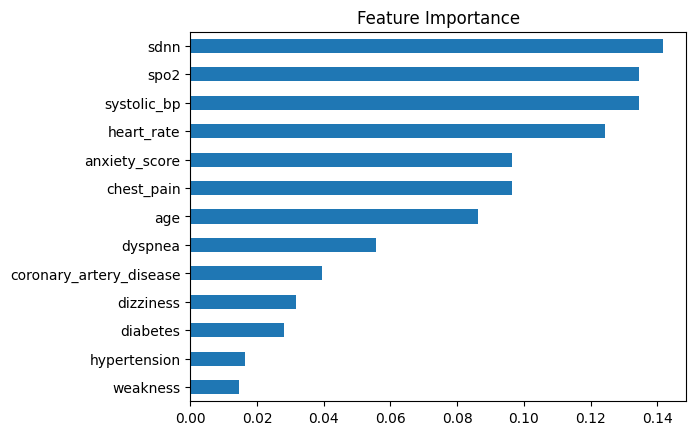

In [8]:
rf=trained['Random Forest']
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values()
imp.plot(kind='barh')
plt.title('Feature Importance')
plt.savefig('feature_importance.png',bbox_inches='tight')
plt.show()